**SALES FORECASTING PROJECT**

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.2 MB/s eta 0:00:00


In [ ]:
# Import library yang akan digunakan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA

import pmdarima as pm

# Import min-max scaling function
from sklearn.preprocessing import MinMaxScaler

# Import keras lstm model
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Bidirectional, GRU, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Metrics
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('store5.csv')
df.head()

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,1452,2013-01-01,5,AUTOMOTIVE,0.0,0,NaN
1,1453,2013-01-01,5,BABY CARE,0.0,0,NaN
2,1454,2013-01-01,5,BEAUTY,0.0,0,NaN
3,1455,2013-01-01,5,BEVERAGES,0.0,0,NaN
4,1456,2013-01-01,5,BOOKS,0.0,0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55572 entries, 0 to 55571
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           55572 non-null  int64  
 1   date         55572 non-null  object 
 2   store_nbr    55572 non-null  int64  
 3   family       55572 non-null  object 
 4   sales        55572 non-null  float64
 5   onpromotion  55572 non-null  int64  
 6   dcoilwtico   38379 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 3.0+ MB


In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
daily_sales = df.groupby('date')['sales'].sum().reset_index()
daily_sales.head()

,date,sales
0,2013-01-01,0.000000
1,2013-01-02,10598.619020
2,2013-01-03,7770.968000
3,2013-01-04,7347.641991
4,2013-01-05,8192.598000


In [ ]:
daily_sales.set_index('date', inplace=True)

In [ ]:
daily_sales

,sales
date,
2013-01-01,0.000000
2013-01-02,10598.619020
2013-01-03,7770.968000
2013-01-04,7347.641991
2013-01-05,8192.598000
...,...
2017-08-11,9510.871000
2017-08-12,8157.070000
2017-08-13,10044.821000


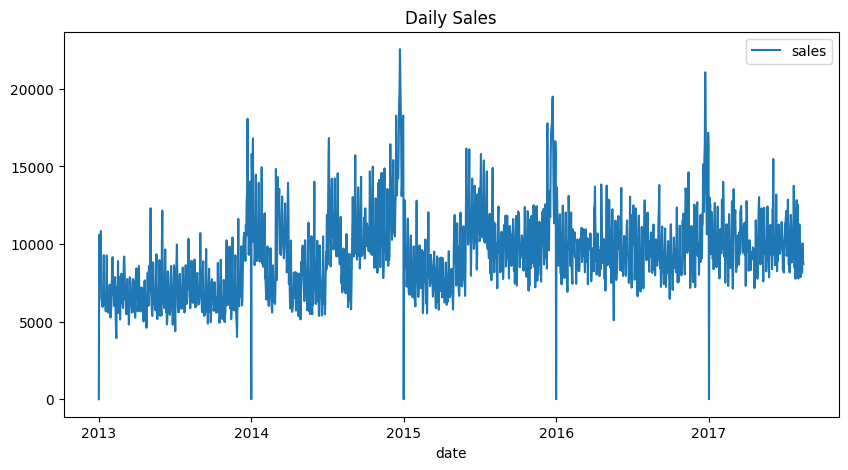

In [ ]:
# Lineplot untuk melihat tren data
plt.figure(figsize=(10,5))
plt.title('Daily Sales')
sns.lineplot(data=daily_sales)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

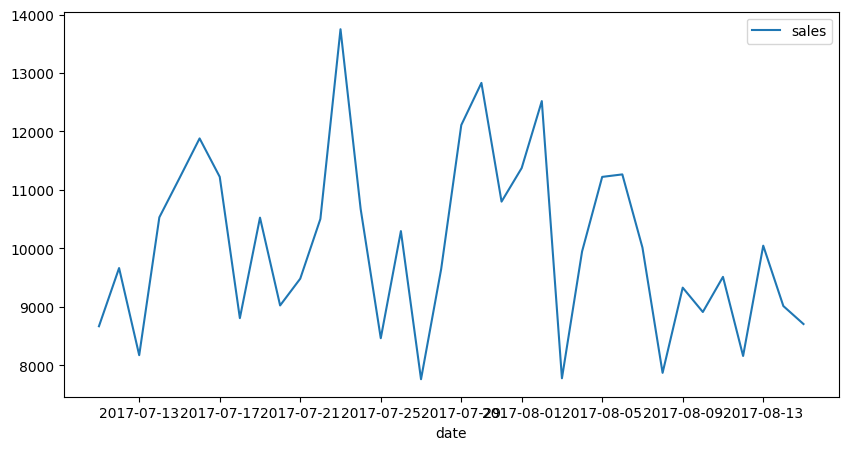

In [ ]:
plt.figure(figsize=(10,5))
# Detail timestamp
sns.lineplot(daily_sales[-36:])
plt.show

<Figure size 1500x500 with 0 Axes>

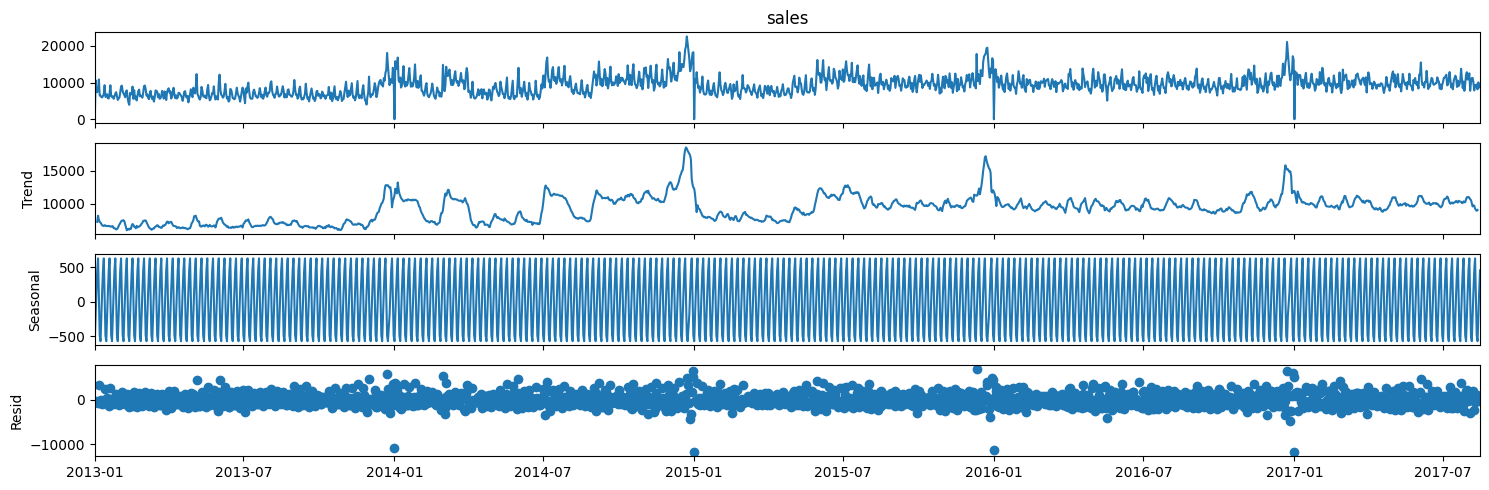

In [ ]:
# Decompose Time Series

# Make fig size bigger
plt.rcParams['figure.figsize'] = (15, 5)
# Decompose time series
decomposition = seasonal_decompose(daily_sales['sales'], model='add', period=7)
fig = plt.figure()
fig = decomposition.plot()

**EDA 1**

Menentukan I (Integrated) pada ARIMA, dan menentukan AR dan MA

Menentukan I (Integrated)

In [ ]:
from statsmodels.tsa.stattools import adfuller
from numpy import log
result = adfuller(daily_sales['sales'].dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -4.648021
p-value: 0.000105


Nilai p-value kurang dari 0.05, yang berarti data adalah stasioner

Menentukan AR dan MA

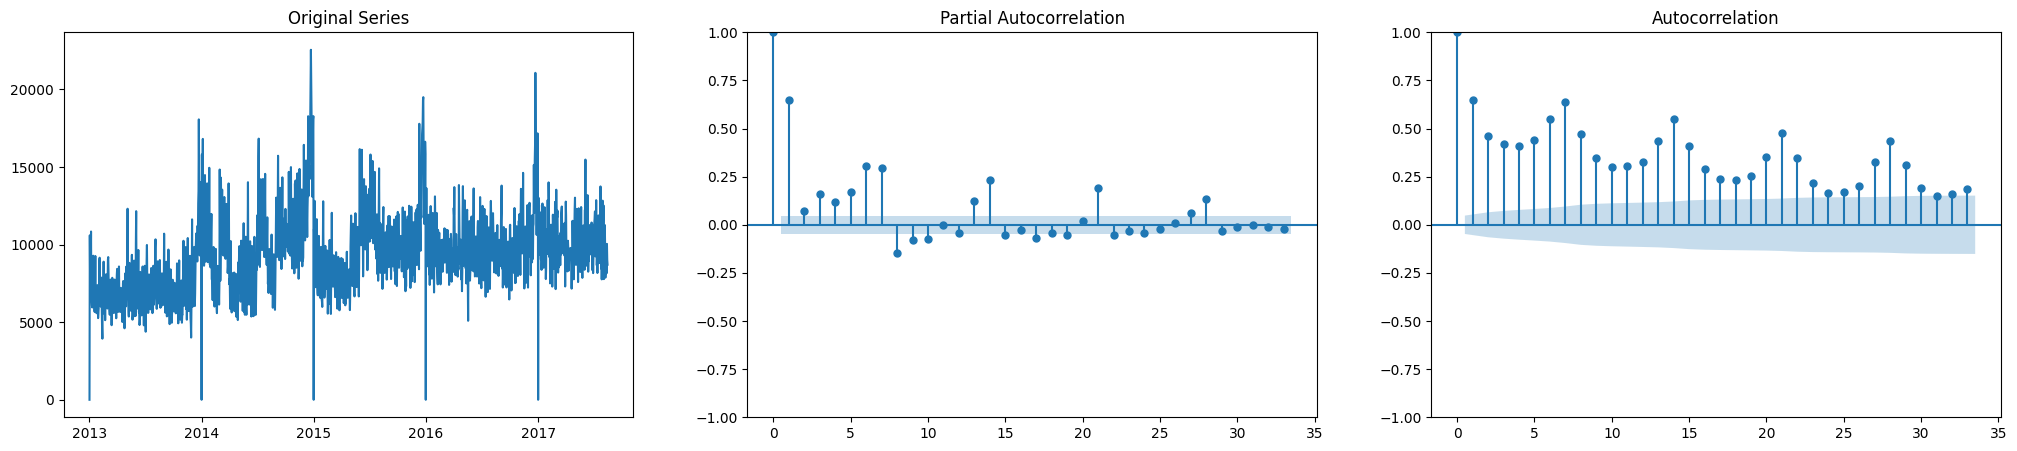

In [ ]:
# Plot ACF dan PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, ax = plt.subplots(1, 3, figsize=(25, 5))

ax[0].set_title('Original Series')
ax[0].plot(daily_sales['sales'])
ax[1] = plot_pacf(daily_sales['sales'], ax=ax[1])
ax[2] = plot_acf(daily_sales['sales'], ax=ax[2])

plt.show()

**Modelling 1**

In [ ]:
train = daily_sales['sales'][:len(daily_sales)-120]
test = daily_sales['sales'][len(daily_sales)-120:]

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
# ARIMA Model
# ARIMA = (p,d,q)

model = ARIMA(train, order=(2,0,1))
model_fit_cross = model.fit()

print(model_fit_cross.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1564
Model:                 ARIMA(2, 0, 1)   Log Likelihood              -13973.639
Date:                Tue, 10 Mar 2026   AIC                          27957.278
Time:                        06:04:25   BIC                          27984.053
Sample:                             0   HQIC                         27967.232
                               - 1564                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       9194.9637    394.295     23.320      0.000    8422.159    9967.768
ar.L1          1.3387      0.026     52.228      0.000       1.288       1.389
ar.L2         -0.3503      0.023    -15.163      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


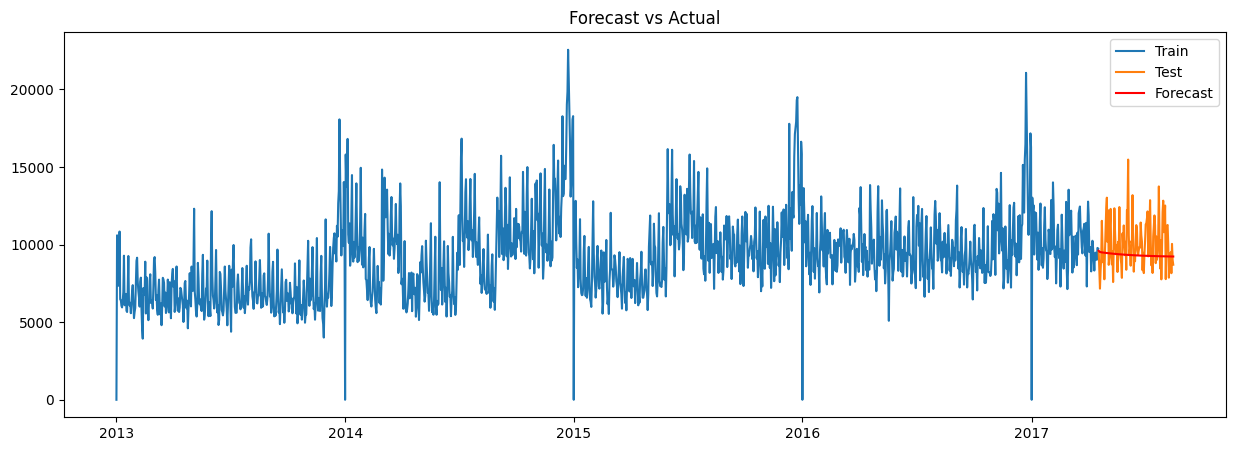

In [ ]:
# Prediction
forecast = model_fit_cross.predict(start=len(train), end=len(train)+len(test)-1, typ='levels')
forecast.index = test.index

plt.figure(figsize=(15,5))
plt.title('Forecast vs Actual')
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(forecast, label='Forecast', color='r')
plt.legend()

In [ ]:
model = pm.auto_arima(train,
                      start_p=0,        # nilai p pertama
                      start_q=0,        # nilai q pertama
                      test='adf',       # gunakan adftest untuk mencari optimal 'd'
                      max_p=3,          # maksimal p
                      max_q=2,          # maksimal q
                      d=0,              # let model determine 'd'
                      seasonal=False,   # Seasonality
                      trace=True,       # print result
                      error_action='ignore',    # we don't want to know if an order does not work
                      suppress_warnings=True,   # we don't want convergence warnings
                      stepwise=True)        # set to stepwise

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=33105.499, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=28382.764, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=31388.906, Time=0.32 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=28313.168, Time=0.24 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.44 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=27974.138, Time=1.18 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=28111.957, Time=0.81 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=27942.317, Time=1.51 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=27911.136, Time=1.49 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=27946.318, Time=2.83 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=28001.599, Time=2.77 sec

Best model:  ARIMA(3,0,2)(0,0,0)[0]          
Total fit time: 11.684 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:            

In [ ]:
# ARIMA Model 2
# ARIMA = (p,d,q)

model = ARIMA(train, order=(3,0,2))
model_fit_cross = model.fit()

print(model_fit_cross.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1564
Model:                 ARIMA(3, 0, 2)   Log Likelihood              -13924.820
Date:                Tue, 10 Mar 2026   AIC                          27863.640
Time:                        06:05:04   BIC                          27901.125
Sample:                             0   HQIC                         27877.575
                               - 1564                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       9195.3316    252.919     36.357      0.000    8699.619    9691.044
ar.L1          1.9686      0.033     59.997      0.000       1.904       2.033
ar.L2         -1.6235      0.040    -41.094      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# =========================
# SAVE BEST MODEL
# =========================
import pickle
pickle.dump(model_fit_cross, open("best_arima_302.pkl", "wb"))

In [ ]:
import pickle

model_arima = pickle.load(open("best_arima_302.pkl","rb"))

In [ ]:
from google.colab import files
files.download("best_arima_302.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


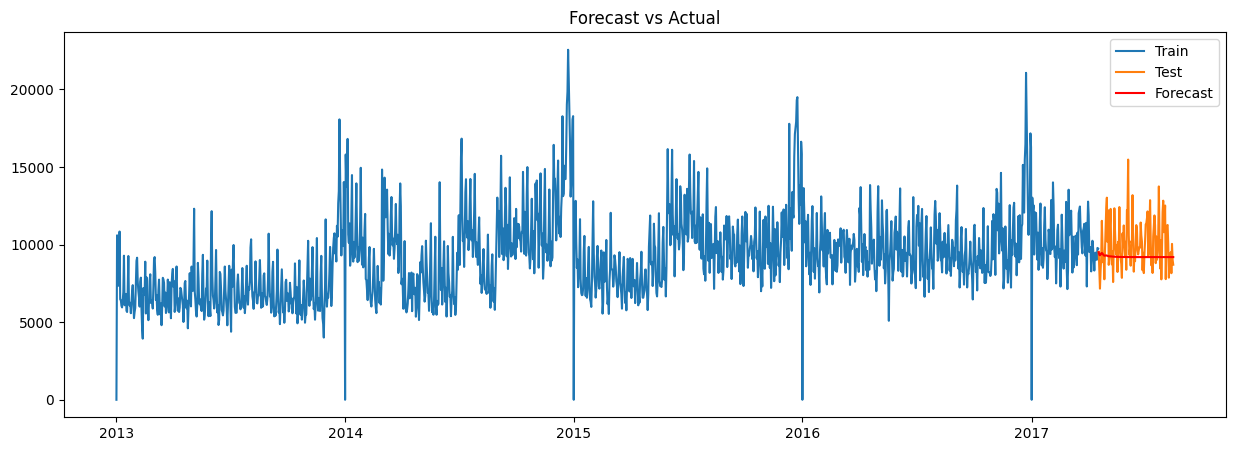

In [ ]:
# Prediction 2
forecast = model_fit_cross.predict(start=len(train), end=len(train)+len(test)-1, typ='levels')
forecast.index = test.index

plt.figure(figsize=(15,5))
plt.title('Forecast vs Actual')
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(forecast, label='Forecast', color='r')
plt.legend()

**EDA 2**

In [ ]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(daily_sales[['sales']])

In [ ]:
def create_dataset(data, time_step=60):
    X, y = [], []

    for i in range(len(data)-time_step):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])

    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data, 30)

In [ ]:
train_size = len(train)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [ ]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

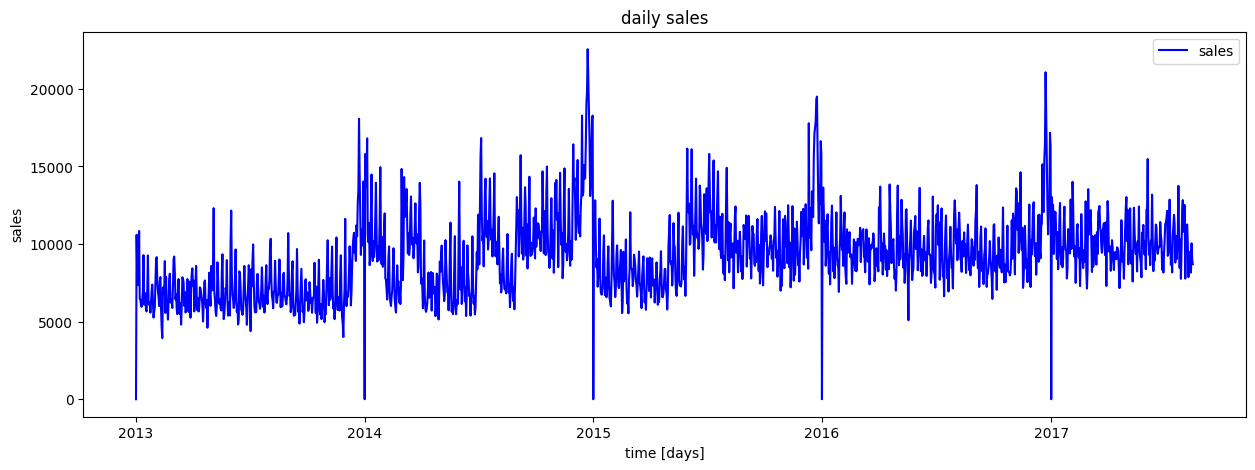

In [ ]:
plt.figure(figsize=(15, 5));
plt.plot(daily_sales['sales'], color='blue', label='sales')
plt.title('daily sales')
plt.xlabel('time [days]')
plt.ylabel('sales')
plt.legend(loc='best')
plt.show()

**Modelling 2**

In [ ]:
model = Sequential()

model.add(LSTM(64, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0406 - val_loss: 0.0044
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0084 - val_loss: 0.0044
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0090 - val_loss: 0.0045
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0081 - val_loss: 0.0045
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0092 - val_loss: 0.0045
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0077 - val_loss: 0.0048
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0082 - val_loss: 0.0054
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0076 - val_loss: 0.0045
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0074 - val_loss: 0.0052
Epoch 10/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0080 - val_loss: 0.0049
Epoch 11/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0073 - val_loss: 0.0054
Epoch 12/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0

In [ ]:
# =========================
# SAVE LSTM MODEL
# =========================
model.save("lstm_model.h5")

In [ ]:
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [ ]:
from google.colab import files
files.download("lstm_model.h5")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Axes: >

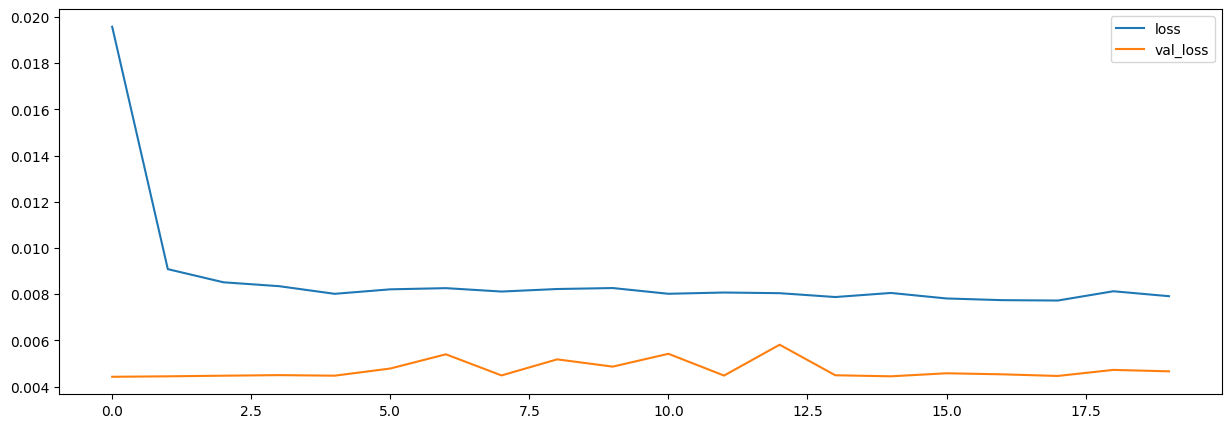

In [ ]:
%matplotlib inline
losses = pd.DataFrame(history.history)
losses.plot()

In [ ]:
pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


In [ ]:
pred = scaler.inverse_transform(pred)

y_test_real = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

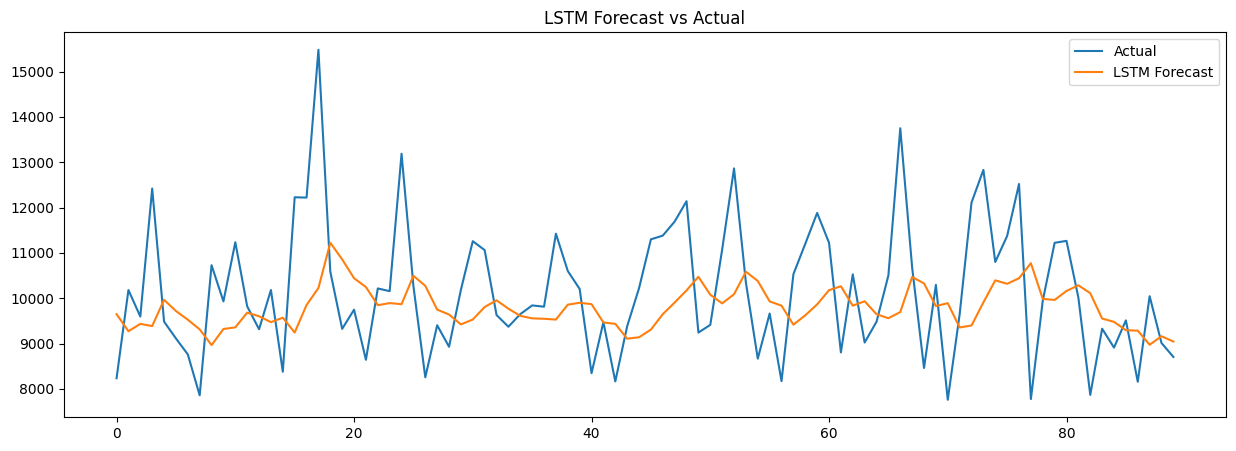

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(y_test_real, label="Actual")
plt.plot(pred, label="LSTM Forecast")

plt.title("LSTM Forecast vs Actual")
plt.legend()
plt.show()

**PERBANDINGAN MODEL**

In [ ]:
forecastARIMA = {'test': test, 'forecast': forecast}
forecastLSTM = {'test': y_test_real.flatten(), 'forecast': pred.flatten()}

r2_scoreARIMA = metrics.r2_score(forecastARIMA['test'], forecastARIMA['forecast'])
print('R2 Score ARIMA:', r2_scoreARIMA)
r2_scoreLSTM = metrics.r2_score(forecastLSTM['test'], forecastLSTM['forecast'])
print('R2 Score LSTM:', r2_scoreLSTM)

R2 Score ARIMA: -0.3577918763997492
R2 Score LSTM: -0.12279181163238961


In [ ]:
# MSE
mseARIMA = mean_squared_error(forecastARIMA['test'], forecastARIMA['forecast'])
print('MSE ARIMA:', mseARIMA)
mseLSTM = mean_squared_error(forecastLSTM['test'], forecastLSTM['forecast'])
print('MSE LSTM:', mseLSTM)

MSE ARIMA: 2940283.2277201475
MSE LSTM: 2373588.217600085


In [ ]:
# RMSE
rmseARIMA = np.sqrt(mseARIMA)
print('RMSE ARIMA:', rmseARIMA)
rmseLSTM = np.sqrt(mseLSTM)
print('RMSE LSTM:', rmseLSTM)

RMSE ARIMA: 1714.7254088396041
RMSE LSTM: 1540.6453899584046


In [ ]:
# MAE
maeARIMA = metrics.mean_absolute_error(forecastARIMA['test'], forecastARIMA['forecast'])
print('MAE ARIMA:', maeARIMA)
maeLSTM = metrics.mean_absolute_error(forecastLSTM['test'], forecastLSTM['forecast'])
print('MAE LSTM:', maeLSTM)

MAE ARIMA: 1298.389677443741
MAE LSTM: 1187.0802312616665


In [ ]:
# MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mapeARIMA = mean_absolute_percentage_error(forecastARIMA['test'], forecastARIMA['forecast'])
print('MAPE ARIMA:', mapeARIMA)
mapeLSTM = mean_absolute_percentage_error(forecastLSTM['test'], forecastLSTM['forecast'])
print('MAPE LSTM:', mapeLSTM)

MAPE ARIMA: 12.02983271450165
MAPE LSTM: 11.40298536025904


In [ ]:
# MASE
def mean_absolute_scaled_error(training_series, testing_series, prediction_series):
    n = training_series.shape[0]
    d = np.abs(  np.diff( training_series) ).sum()/(n-1)
    errors = np.abs(testing_series - prediction_series )
    return errors.mean()/d

maseARIMA = mean_absolute_scaled_error(train, test, forecastARIMA['forecast'])
print('MASE ARIMA:', maseARIMA)
maseLSTM = mean_absolute_scaled_error(train, test[-len(forecastLSTM['forecast']):], forecastLSTM['forecast'])
print('MASE LSTM:', maseLSTM)

MASE ARIMA: 0.8462765743677846
MASE LSTM: 0.7737262618951849


In [ ]:
comparison = pd.DataFrame({
    'Metric':['R2','MSE','RMSE','MAE','MAPE','MASE'],
    'ARIMA':[r2_scoreARIMA,mseARIMA,rmseARIMA,maeARIMA,mapeARIMA,maseARIMA],
    'LSTM':[r2_scoreLSTM,mseLSTM,rmseLSTM,maeLSTM,mapeLSTM,maseLSTM]
})

print(comparison)

  Metric         ARIMA          LSTM
0     R2 -3.577919e-01 -1.227918e-01
1    MSE  2.940283e+06  2.373588e+06
2   RMSE  1.714725e+03  1.540645e+03
3    MAE  1.298390e+03  1.187080e+03
4   MAPE  1.202983e+01  1.140299e+01
5   MASE  8.462766e-01  7.737263e-01
